In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.correlation as correlation
%matplotlib inline

# Load Data

In [2]:
# Define path to data
DATA_DIR = Path("/data/")
# Load data frame of cells, and networkx graphs
dataDF, graphs = utils.load_cells(DATA_DIR)

Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


# Correlation Matrix for original data

In [3]:
# Build Correlation Matrix for data based on axon length in each brain region
df = clustering.build_length_df(dataDF, graphs, DATA_DIR)
sorted_columns = ['OLF','Isocortex','HPF','CTXsp','CNU','TH','HY','MB','CB','P','MY','Other']
df = df[sorted_columns]

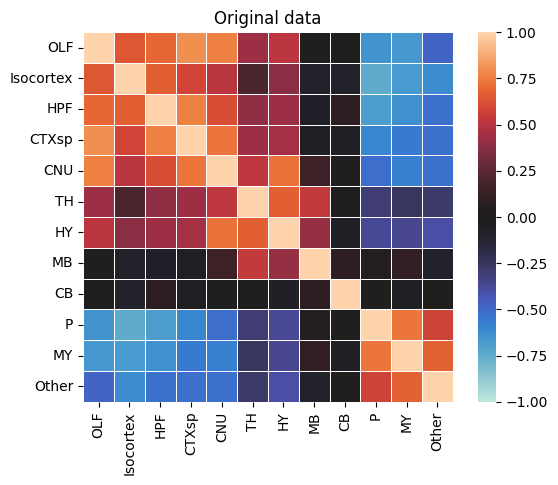

In [4]:
correlation.plot_correlation(df)

# Correlation Matrix for shuffled data

This analysis shuffles each cell's projections across brain regions. This means we are shuffling each row of the data matrix

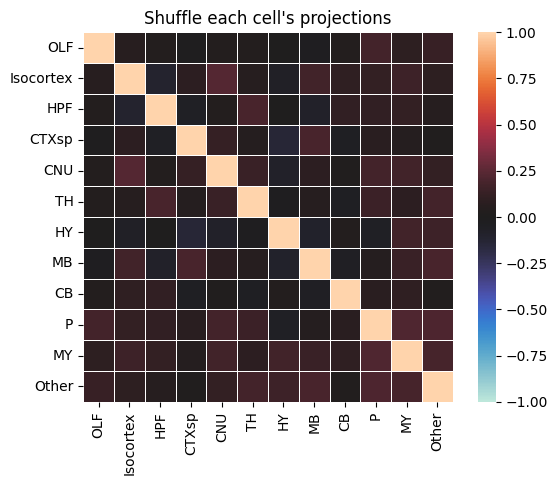

In [5]:
correlation.plot_shuffle_row(df)

# Test significance of shuffle

We can use Jennrich's Test for the equality of correlation matrices. To do this, we use a bootstrapping approach with the shuffled data. We shuffle the data matrix 10,000 times. For each shuffled data set we generate the correlation matrix and then compute the Chi-Squared statistic between the true correlation matrix and the shuffled data correlation matrix. Then we look at the distribution of these bootstrapped statistics and ask what percentage of them are greater than the significance threshold with alpha=0.05. If this probability is less than alpha, then we can reject the null hypothesis that the original data is from the same distribution as the shuffled data. 

In [ ]:
correlation.test_shuffle_row(df,n=10000,alpha=0.05)

# Correlation Matrix for random Projections

This test is slightly different, instead of shuffling each cell's projection patterns, we draw a random vector in R^12 (12 brain regions), then normalize it to have unit length. 

In [ ]:
correlation.plot_random_projections(df)

We can then test this distribution in the same manner with bootstrapping

In [8]:
correlation.test_random_projections(df, n=10000, alpha=0.05)

Probability of observing data in shuffle distribution: 0.0


# Correlation matrix for shuffling columns

Here we shuffle the projections to a specific brain region across cells. This means shuffling each column of the data matrix. To do this we have to first load the unnormalized length data. 

In [9]:
df_unnormalized = clustering.build_length_df(dataDF, graphs, DATA_DIR, normalize_df = False)

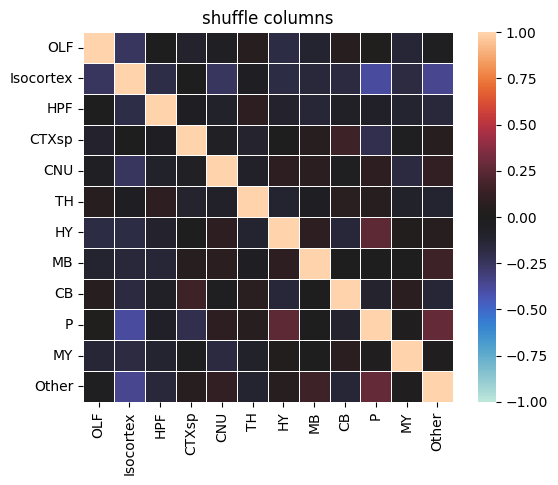

In [10]:
correlation.plot_shuffle_columns(df_unnormalized)

In [11]:
correlation.test_shuffle_columns(df, df_unnormalized, n=10000, alpha=0.05)

Probability of observing data in shuffle distribution: 0.0


# Are there groups of brain structures for which projections are random?

Examining the correlation matrix, we observe two groups of correlated brain structures, one posterior and one anterior. In order to ask about the significance of structure within those groups we can shuffle just between those brain regions.

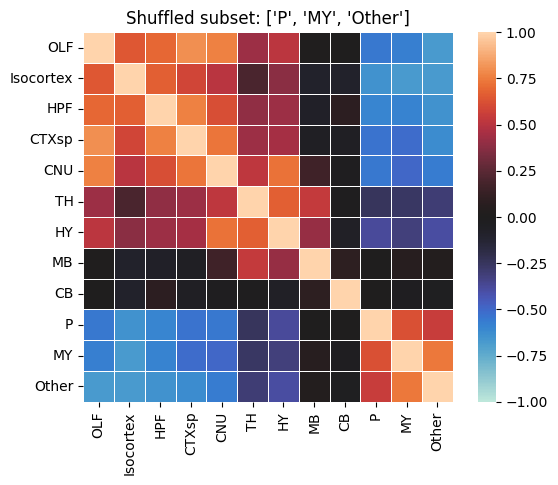

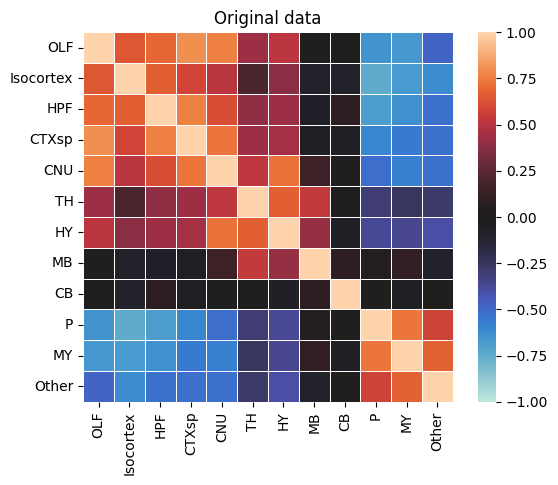

In [12]:
posterior_group = ['P','MY','Other']
correlation.plot_shuffle_row_group(df, posterior_group)
correlation.plot_correlation(df)

We can use the same statistical approach, but we have one additional decision to make. We could compare just the 3x3 correlation matrix of these three brain structures, or we could compare the full 12x12 correlation matrix. If we look at the full 12x12 correlation matrix this is more conservative, although we need to adjust the degrees of freedom to reflect the fact that the 9x9 sub-matrix will have identicial entries to the original data. 

In [13]:
correlation.test_shuffle_row_group(df, posterior_group, n=10000, alpha=0.05)

Probability of observing data in shuffle distribution: 0.6707000000000001


In [14]:
correlation.test_shuffle_row_group(df, posterior_group, n=10000, alpha=0.05, use_full=True)

Probability of observing data in shuffle distribution: 0.13370000000000004


For both tests, we cannot reject the null hypothesis. This means that the correlation between projection strengths between these three brain regions is statistically the same as randomly shuffled. 

### Sanity checks

We can also check to see if this result is sensitive to inclusion or exclusion of cells that project weakly to these regions. 

Text(0, 0.5, 'Percentage of axon length in posterior group')

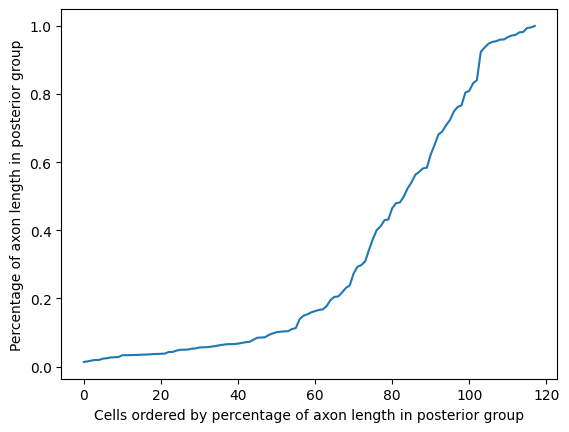

In [15]:
df['posterior_sum'] = df['P'] + df['MY'] + df['Other']
plt.figure()
plt.plot(np.sort(df['posterior_sum'].values))
plt.xlabel('Cells ordered by percentage of axon length in posterior group')
plt.ylabel('Percentage of axon length in posterior group')

Probability of observing data in shuffle distribution: 0.9097999999999999


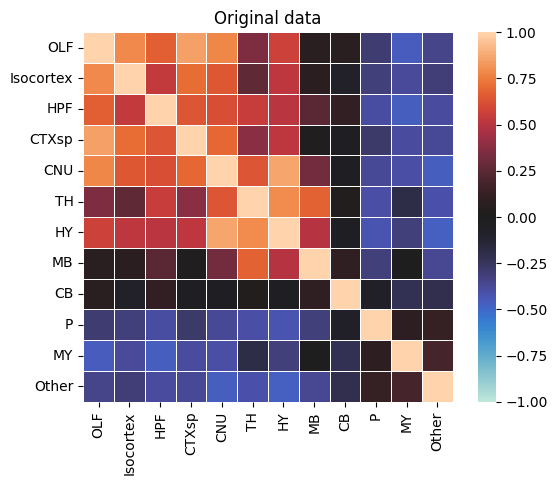

In [16]:
correlation.plot_correlation(df.query('posterior_sum > .2'))
correlation.test_shuffle_row_group(df.query('posterior_sum > .2'), posterior_group, n=10000, alpha=0.05, use_full=True)

Probability of observing data in shuffle distribution: 0.19989999999999997


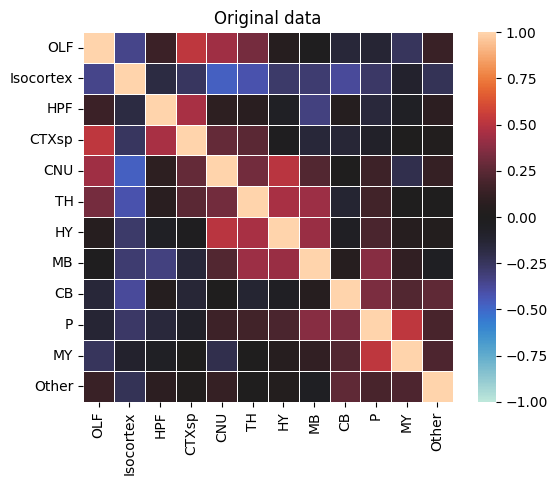

In [17]:
correlation.plot_correlation(df.query('posterior_sum < .2'))
correlation.test_shuffle_row_group(df.query('posterior_sum < .2'), posterior_group, n=10000, alpha=0.05, use_full=True)

Probability of observing data in shuffle distribution: 0.01959999999999995


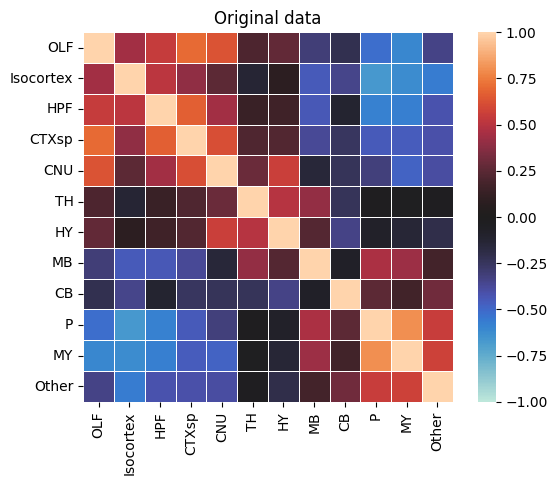

In [18]:
correlation.plot_correlation(df.query('posterior_sum < .8'))
correlation.test_shuffle_row_group(df.query('posterior_sum < .8'), posterior_group, n=10000, alpha=0.05, use_full=True)

# Testing the anterior projection group

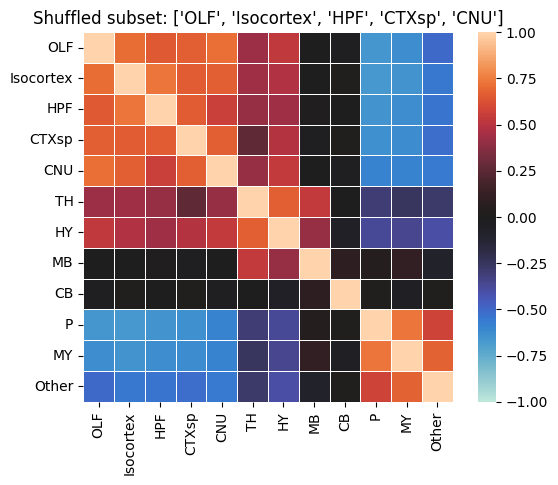

In [20]:
anterior_group = ['OLF','Isocortex','HPF','CTXsp','CNU']
correlation.plot_shuffle_row_group(df, anterior_group)

In [21]:
correlation.test_shuffle_row_group(df, anterior_group, n=10000, alpha=0.05, use_full=True)

Probability of observing data in shuffle distribution: 0.0


Here, p = 0, meaning we reject the null-hypothesis that the projection patterns between these brain regions are random. We can also explore a smaller subset of regions.  

Probability of observing data in shuffle distribution: 0.0039000000000000146


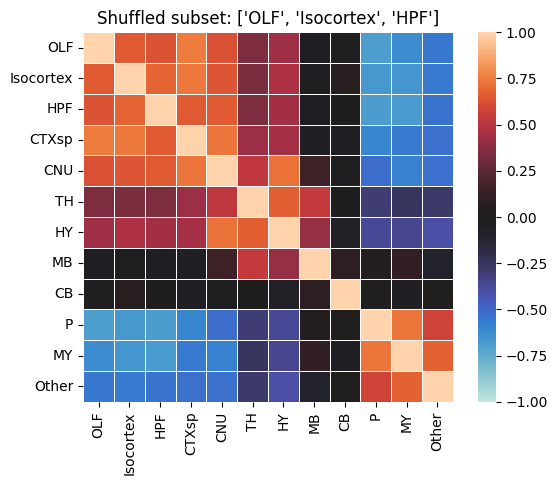

In [22]:
anterior_group = ['OLF','Isocortex','HPF']
correlation.plot_shuffle_row_group(df, anterior_group)
correlation.test_shuffle_row_group(df, anterior_group, n=10000, alpha=0.05, use_full=True)

Text(0, 0.5, 'Percentage of axon length in anterior group')

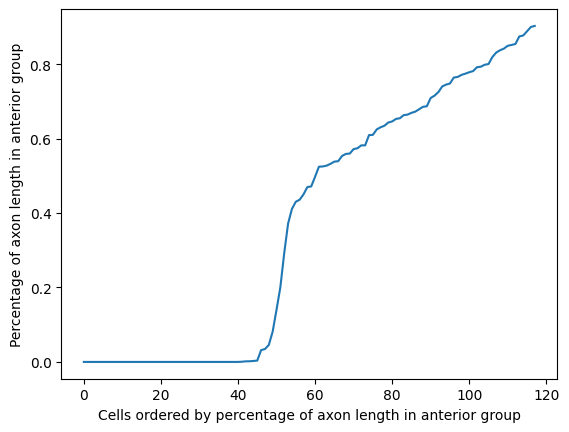

In [23]:
df['anterior_sum'] = df['OLF'] + df['Isocortex'] + df['HPF']
plt.figure()
plt.plot(np.sort(df['anterior_sum'].values))
plt.xlabel('Cells ordered by percentage of axon length in anterior group')
plt.ylabel('Percentage of axon length in anterior group')

Probability of observing data in shuffle distribution: 0.0


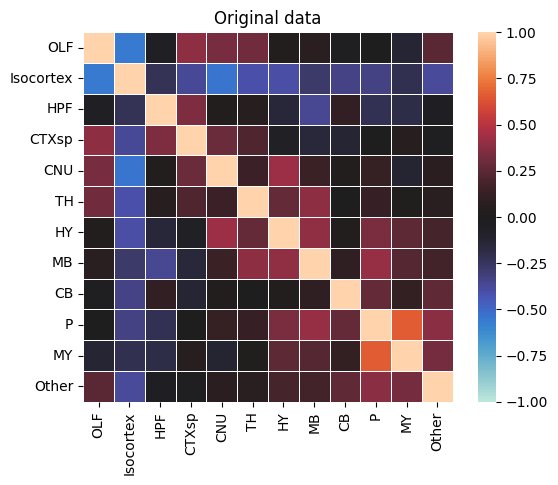

In [24]:
correlation.plot_correlation(df.query('anterior_sum > .1'))
correlation.test_shuffle_row_group(df.query('anterior_sum > .1'), anterior_group, n=10000, alpha=0.05, use_full=True)

Probability of observing data in shuffle distribution: 0.0


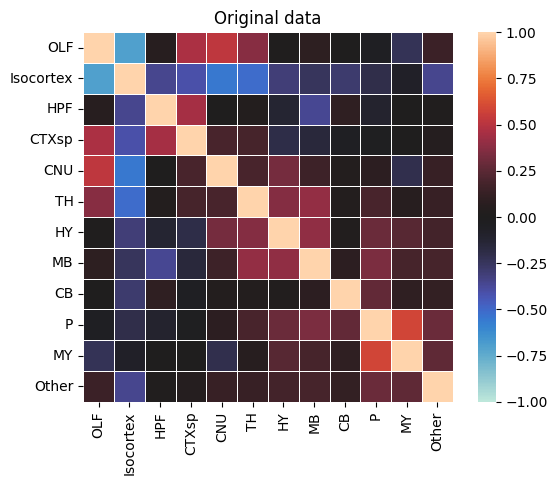

In [25]:
correlation.plot_correlation(df.query('anterior_sum > .5'))
correlation.test_shuffle_row_group(df.query('anterior_sum > .5'), anterior_group, n=10000, alpha=0.05, use_full=True)

# Summary

We can easily rule out the null-model that all cells randomly project to different brain regions. We can also rule out the null model that cells project either anterior or posterior, and then randomly distribute their axons.